In [1]:
# Setup

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

device = 'cuda' if torch.cuda.is_available() else 'cpu'

if device == 'cuda' and torch.cuda.is_bf16_supported():
    dtype = torch.bfloat16
elif device == 'cuda':
    dtype = torch.float16
else:
    dtype = torch.float32

# config
batch_size = 64
dim = 64
n_heads = 4
head_dims = dim // n_heads
n_layers = 4
mlp_dim = 1024
block_size = 256

with open("input.txt", "r") as f:
    text = f.read()

chars = sorted(set(text))
vocab_size = len(chars)
stoi = {c:i for i,c in enumerate(chars)}
itos = {i:c for c,i in stoi.items()}
encode = lambda s: [stoi[c] for c in s]
decode = lambda l: ''.join([itos[i] for i in l])
char_label = lambda c: {' ': '<space>', '\n': '<newline>', '\t': '<tab>'}.get(c, c)

tokens = torch.tensor(encode(text), device=device)
n = len(tokens)
train_seqs = tokens[:int(0.8 * n)].unfold(0, block_size + 1, 1)

def rmsnorm(x, eps=1e-5):
    return x / ((x ** 2).mean(dim=-1, keepdim=True).sqrt() + eps)

def forward(x, stop_after=None, steer_layer=None, steer_vec=None, return_attn=False):
    B, T = x.shape
    x = emb[x] + pos[:T]
    mask = torch.tril(torch.ones(T, T, device=device, dtype=torch.bool))
    attn_weights = [] if return_attn else None

    last_layer = stop_after if stop_after is not None else n_layers - 1
    for layer in range(last_layer + 1):
        nx = rmsnorm(x)

        q, k, v = nx @ wq[layer], nx @ wk[layer], nx @ wv[layer]
        q = q.view(B,T,n_heads,head_dims).transpose(1,2)
        k = k.view(B,T,n_heads,head_dims).transpose(1,2)
        v = v.view(B,T,n_heads,head_dims).transpose(1,2)

        scores = q @ k.transpose(-2, -1) / (head_dims ** 0.5)
        scores = scores.masked_fill(~mask, float('-inf'))
        attn = F.softmax(scores, dim=-1)
        if return_attn:
            attn_weights.append(attn.detach())
        attn_out = (attn @ v).transpose(1,2).contiguous().view(B, T, dim)
        x = x + attn_out @ wo[layer]

        nx = rmsnorm(x)
        x = x + (nx @ w1[layer]).relu() @ w2[layer]

        if layer == steer_layer and steer_vec is not None:
            x[0, -1] += steer_vec

    if stop_after is not None:
        return x

    x = rmsnorm(x)
    x = x @ emb.T
    if return_attn:
        return x, attn_weights
    return x

In [2]:
# Load Weights

def load_weights(path="shakesp_minimal_transformer_weights.pt"):
    global emb, pos, wq, wk, wv, wo, w1, w2
    ckpt = torch.load(path, map_location=device, weights_only=True)
    emb, pos = ckpt['emb'], ckpt['pos']
    wq, wk, wv, wo = ckpt['wq'], ckpt['wk'], ckpt['wv'], ckpt['wo']
    w1, w2 = ckpt['w1'], ckpt['w2']
    print(f"Loaded from {path}")

load_weights()

Loaded from shakesp_minimal_transformer_weights.pt


In [3]:
# Generate

ctx = "Firs"
tokens = encode(ctx)

for _ in range(100):
    x = torch.tensor([tokens[-block_size:]], device=device)
    logits = forward(x)
    # probs = F.softmax(logits[0, -1] / 0.8, dim=-1)
    # tokens.append(torch.multinomial(probs, 1).item())
    tokens.append(logits[0, -1].argmax().item())

print(decode(tokens))

First George MiRCEN:
The loss of the man that has most married the ower,
And there and the seat of the c


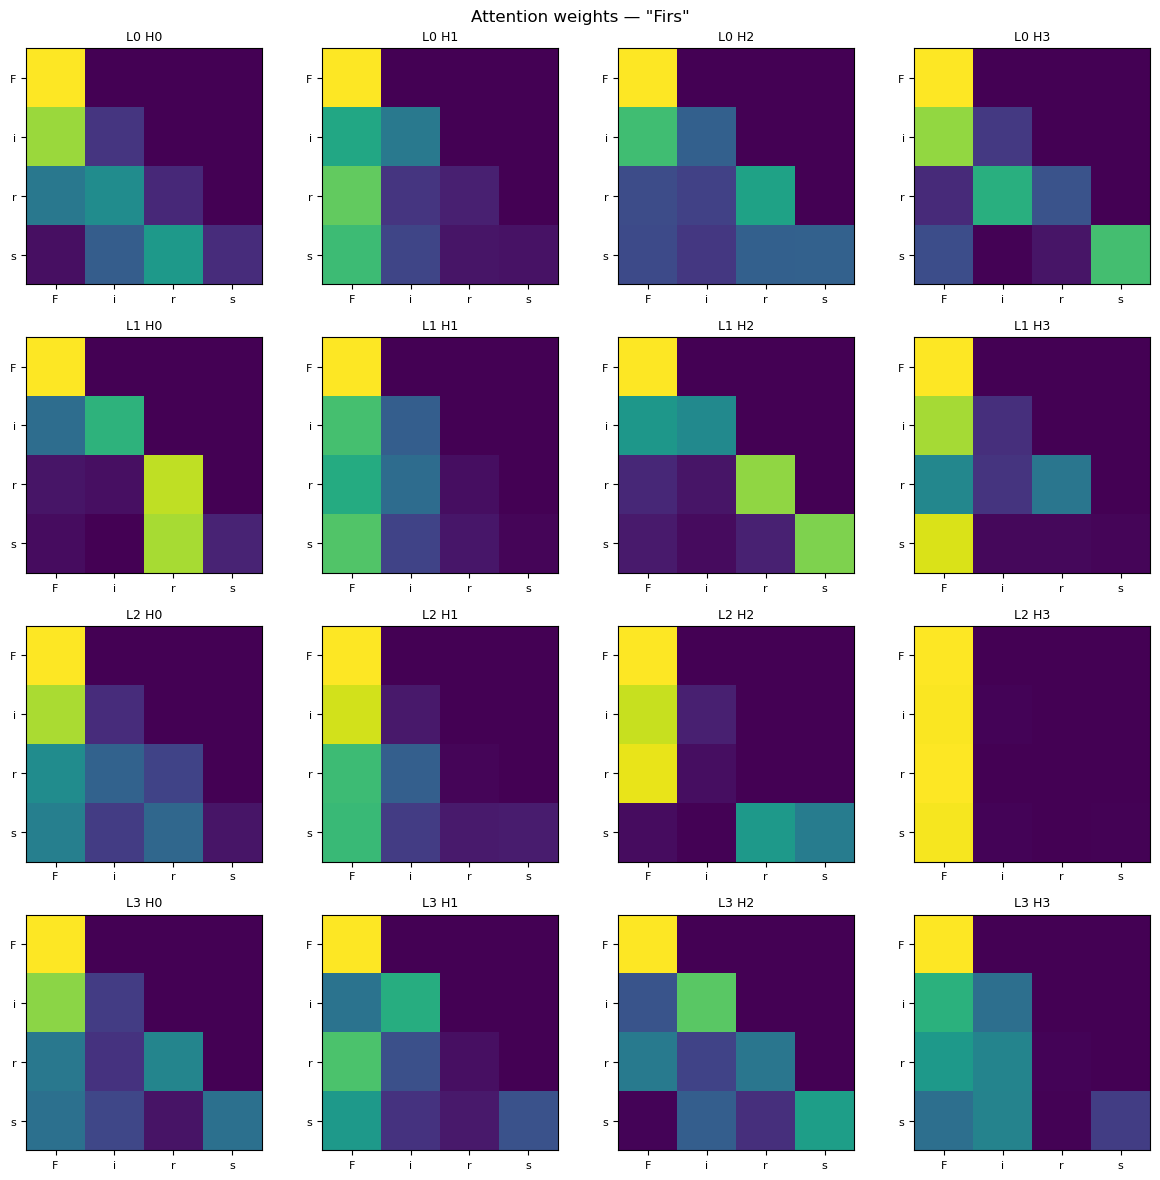

In [4]:
# Attention Heatmap

text_input = "Firs"
tok = torch.tensor([encode(text_input)], device=device)
T = tok.shape[1]

_, attn_weights = forward(tok, return_attn=True)

fig, axes = plt.subplots(n_layers, n_heads, figsize=(3 * n_heads, 3 * n_layers))
if n_layers == 1 and n_heads == 1:
    axes = np.array([[axes]])
elif n_layers == 1:
    axes = axes[np.newaxis, :]
elif n_heads == 1:
    axes = axes[:, np.newaxis]

labels = [repr(c) if c in (' ', '\n', '\t') else c for c in text_input]

for layer in range(n_layers):
    for h in range(n_heads):
        ax = axes[layer, h]
        w = attn_weights[layer][0, h].float().cpu().numpy()
        ax.imshow(w, cmap='viridis', vmin=0, vmax=1)
        ax.set_xticks(range(T)); ax.set_xticklabels(labels, fontsize=8)
        ax.set_yticks(range(T)); ax.set_yticklabels(labels, fontsize=8)
        ax.set_title(f'L{layer} H{h}', fontsize=9)

plt.suptitle(f'Attention weights — "{text_input}"', fontsize=12)
plt.tight_layout()
plt.show()

SAE done. recon=0.1805, alive=78.4%


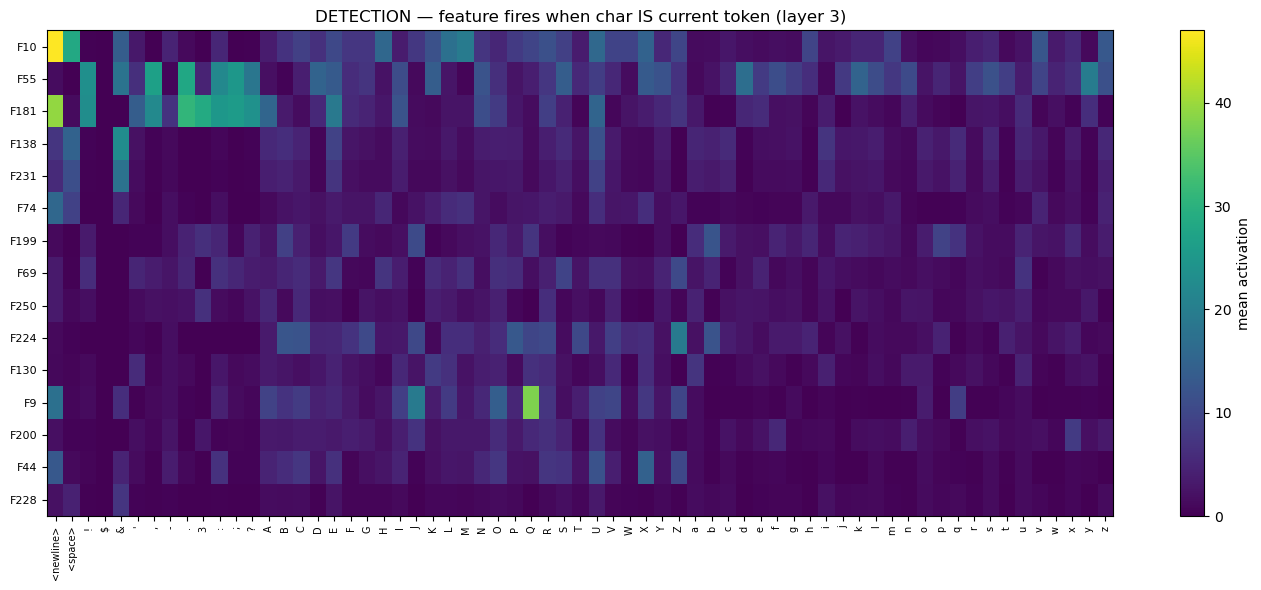

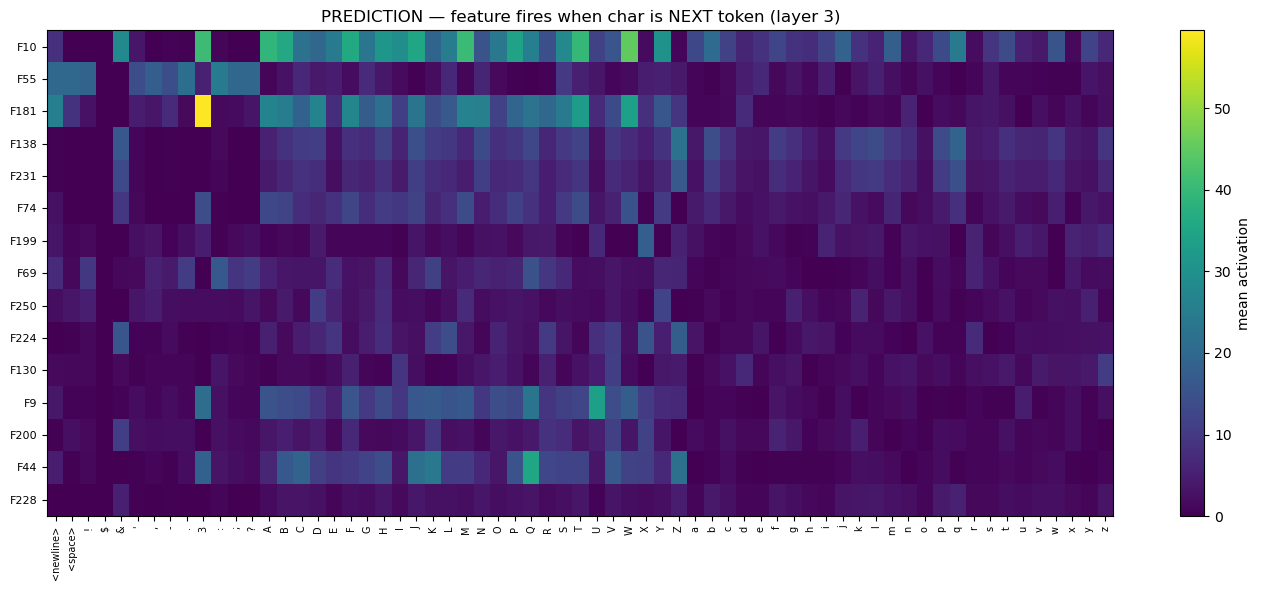

In [5]:
# SAE + Steering

sae_dim = 256
sae_layer = 3
sae_lr = 1e-3
sae_steps = 4000
sae_l1_lambda = 0.02
n_batches = 5

sae_enc = torch.randn(dim, sae_dim, device=device, dtype=torch.float32) * 0.01
sae_dec = torch.randn(sae_dim, dim, device=device, dtype=torch.float32) * 0.01
sae_enc_b = torch.zeros(sae_dim, device=device, dtype=torch.float32)
sae_dec_b = torch.zeros(dim, device=device, dtype=torch.float32)
sae_params = [sae_enc, sae_dec, sae_enc_b, sae_dec_b]
for p in sae_params:
    p.requires_grad = True

sae_encode = lambda x: F.relu(x @ sae_enc + sae_enc_b)

# Collect activations at sae_layer
@torch.no_grad()
def collect_activations(seqs):
    all_acts, all_toks, all_targets = [], [], []
    for _ in range(n_batches):
        idx = torch.randint(0, seqs.shape[0], (batch_size,))
        x_in, x_tgt = seqs[idx, :-1], seqs[idx, 1:]
        all_acts.append(forward(x_in, stop_after=sae_layer).view(-1, dim).float())
        all_toks.append(x_in.view(-1))
        all_targets.append(x_tgt.view(-1))
    return torch.cat(all_acts), torch.cat(all_toks), torch.cat(all_targets)

acts, toks, targets = collect_activations(train_seqs)

# Train SAE
sae_opt = torch.optim.Adam(sae_params, lr=sae_lr)
for step in range(sae_steps):
    batch = acts[torch.randint(0, acts.shape[0], (512,))]
    h = sae_encode(batch)
    recon_loss = (batch - (h @ sae_dec + sae_dec_b)).pow(2).mean()
    l1_loss = h.abs().mean()
    loss = recon_loss + sae_l1_lambda * l1_loss
    sae_opt.zero_grad(); loss.backward(); sae_opt.step()
print(f"SAE done. recon={recon_loss.item():.4f}, alive={(h > 0).float().mean().item():.1%}")

# Encode all activations once, reuse everywhere
h_all = sae_encode(acts).detach()
fire_rate = (h_all > 0).float().mean(dim=0)

def rank_features(top_n=15):
    valid = ((fire_rate > 0.01) & (fire_rate < 0.5)).nonzero().squeeze(-1)
    if len(valid) == 0: return None
    return valid[h_all[:, valid].mean(dim=0).argsort(descending=True)][:top_n]

# Heatmap: mean SAE activation per feature per char
def plot_heatmap(token_ids, title, top_n=15):
    ranked = rank_features(top_n)
    if ranked is None: return
    grid = torch.zeros(len(ranked), vocab_size)
    for i, f in enumerate(ranked):
        for c in range(vocab_size):
            m = (token_ids == c)
            if m.any(): grid[i, c] = h_all[m, f].mean().item()
    plt.figure(figsize=(14, max(3, len(ranked) * 0.4)))
    plt.imshow(grid.numpy(), aspect='auto', cmap='viridis')
    plt.xticks(range(vocab_size), [char_label(itos[c]) for c in range(vocab_size)], fontsize=7, rotation=90)
    plt.yticks(range(len(ranked)), [f"F{f.item()}" for f in ranked], fontsize=8)
    plt.colorbar(label='mean activation'); plt.title(title); plt.tight_layout(); plt.show()

plot_heatmap(toks, f'DETECTION — feature fires when char IS current token (layer {sae_layer})')
plot_heatmap(targets, f'PREDICTION — feature fires when char is NEXT token (layer {sae_layer})')

# Steering: inject sae_dec direction at sae_layer, compare normal vs steered top-5
@torch.no_grad()
def steer(text, sae_dec_i, strength):
    tok = torch.tensor([encode(text)], device=device)
    top5 = lambda lg: [(char_label(itos[i.item()]), f"{v.item():.1%}") for v, i in zip(*F.softmax(lg, dim=-1).topk(5))]
    normal_logits = forward(tok)[0, -1]
    steered_logits = forward(tok, steer_layer=sae_layer, steer_vec=sae_dec_i.float() * strength)[0, -1]
    print(f'Input: "{text}"')
    print(f"  Normal:  {top5(normal_logits)}")
    print(f"  Steered: {top5(steered_logits)}")

# Find which feature most activates when predicting a given char
def find_feature_for_predicting(char):
    mask = (targets == stoi[char])
    if not mask.any(): return None
    feat = h_all[mask].mean(dim=0).argmax().item()
    print(f"Prediction feature for '{char_label(char)}': F{feat}")
    return feat

In [6]:
feat = find_feature_for_predicting(',')
steer("To be or not to be", sae_dec[feat], 2000.0)

Prediction feature for ',': F57
Input: "To be or not to be"
  Normal:  [('<space>', '64.5%'), ('h', '21.6%'), ('a', '6.8%'), ('d', '1.8%'), ('g', '1.5%')]
  Steered: [(',', '94.9%'), (';', '3.7%'), ('.', '0.8%'), ('?', '0.3%'), ('<newline>', '0.1%')]
